In [12]:
URL = r"C:\\Users\\User\\Desktop\\Avances Asignación 03\\Python\\Output\\"

# Part 1a - Real life examples (2 points)


## 1.1) Explanation of Key Concepts (0.5 pts)

- **Confounder**  
  A confounder is a variable that simultaneously affects both the treatment (cause) and the outcome (effect). If not properly controlled, it generates a spurious or biased association, leading to incorrect inferences about causality.

- **Collider**  
  A collider is a variable that is influenced by two or more other variables. Conditioning on a collider (e.g., by including it as a control in regression analysis) can induce a false correlation between its determinants, thereby distorting the estimated relationships.

- **Mediator**  
  A mediator is a variable located on the causal pathway between the treatment and the outcome. It provides insight into the mechanism through which the treatment exerts its effect, helping to distinguish direct from indirect causal impacts.

## 1.2) Economics examples (1 pt)

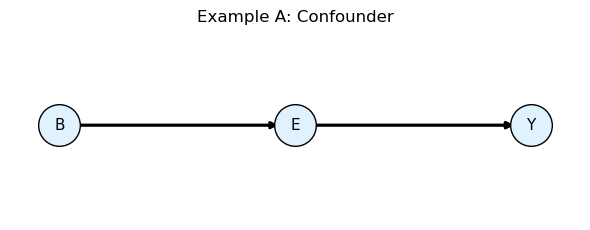

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
G.add_edges_from([("B","E"), ("E","Y"), ("B","Y")])

pos = {
    "B": (0.0, 0.6),
    "E": (1.2, 0.6),
    "Y": (2.4, 0.6),
}

plt.figure(figsize=(6,2.4))
nx.draw_networkx_nodes(G, pos, node_size=900, node_color="#e0f2fe", edgecolors="black")
nx.draw_networkx_labels(G, pos, font_size=11)
nx.draw_networkx_edges(
    G, pos,
    edgelist=[("B","E"), ("E","Y"), ("B","Y")],
    arrows=True, arrowstyle="-|>", min_source_margin=10, min_target_margin=12,
    width=2
)
plt.title("Example A: Confounder", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.savefig( URL + "Confounder.png", dpi=300, bbox_inches="tight")
plt.show()


### Example A: Confounder 
- **Treatment (E):** Years of education
- **Outcome (Y):** Future income
- **Confounder (B):** Family background (socioeconomic status)
- **Explanation:** Family background affects both the likelihood of obtaining more education and the level of income. If not controlled, the estimated effect of education on income will be biased.

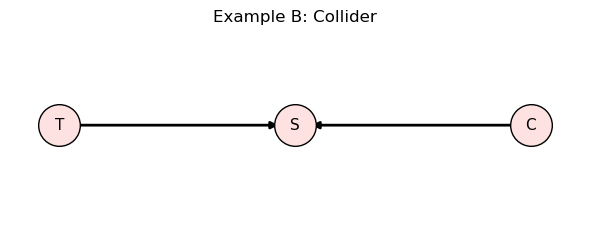

In [15]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
G.add_edges_from([("T","S"), ("C","S")])

pos = {
    "T": (0.0, 0.6),
    "S": (1.2, 0.6),
    "C": (2.4, 0.6),
}

plt.figure(figsize=(6,2.4))
nx.draw_networkx_nodes(G, pos, node_size=900, node_color="#fee2e2", edgecolors="black")
nx.draw_networkx_labels(G, pos, font_size=11)
nx.draw_networkx_edges(
    G, pos,
    edgelist=[("T","S"), ("C","S")],
    arrows=True, arrowstyle="-|>", min_source_margin=10, min_target_margin=12,
    width=2
)
plt.title("Example B: Collider", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.savefig(URL + "Collider.png", dpi=300, bbox_inches="tight")
plt.show()


### Example B: Collider  
- **Variable 1 (T):** Entrepreneurial talent  
- **Variable 2 (C):** Access to credit  
- **Collider (S):** Business survival  
- **Explanation:** Both talent and credit independently increase the chance of business survival. If we condition on survival (look only at businesses that survived), we may see a spurious negative correlation between talent and credit, even if none exists in the population.  

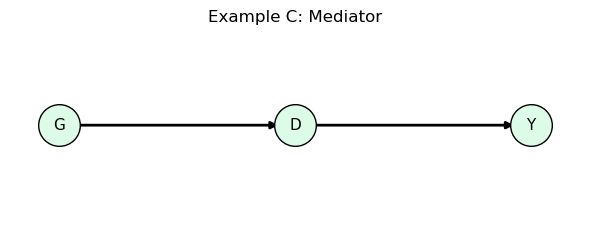

In [14]:
# DAG: Mediator (G → D → Y)
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
G.add_edges_from([("G","D"), ("D","Y")])

# Posiciones fijas izquierda→derecha
pos = {
    "G": (0.0, 0.6),
    "D": (1.2, 0.6),
    "Y": (2.4, 0.6),
}

plt.figure(figsize=(6,2.4))
nx.draw_networkx_nodes(G, pos, node_size=900, node_color="#dcfce7", edgecolors="black")
nx.draw_networkx_labels(G, pos, font_size=11)
nx.draw_networkx_edges(
    G, pos,
    edgelist=[("G","D"), ("D","Y")],
    arrows=True, arrowstyle="-|>", min_source_margin=10, min_target_margin=12,
    width=2
)
plt.title("Example C: Mediator", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.savefig( URL + "Mediator.png", dpi=300, bbox_inches="tight")
plt.show()


### Example C: Mediator  
- **Treatment (G):** Government spending  
- **Mediator (D):** Aggregate demand  
- **Outcome (Y):** Economic growth  
- **Explanation:** Government spending boosts aggregate demand, which then fosters economic growth. Aggregate demand transmits the effect of spending onto growth, so it is a mediator.  

# Part 1b - Simpson's paradox (2 points)


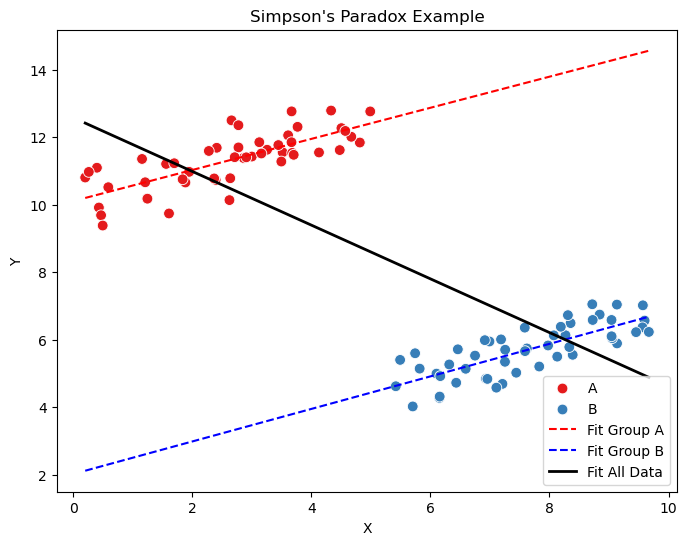

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Reproducibility
rng = np.random.default_rng(222)

# Group A: X between 0 and 5, Y with high intercept
X_A = rng.uniform(0, 5, 50)
Y_A = 0.5 * X_A + 10 + rng.normal(0, 0.5, 50)

# Group B: X between 5 and 10, Y with low intercept
X_B = rng.uniform(5, 10, 50)
Y_B = 0.5 * X_B + 2 + rng.normal(0, 0.5, 50)

# Combine into dataframe
df = pd.DataFrame({
    "X": np.concatenate([X_A, X_B]),
    "Y": np.concatenate([Y_A, Y_B]),
    "Group": ["A"]*50 + ["B"]*50
})

# Fit regressions: by group and combined
def fit_line(x, y):
    Xc = sm.add_constant(x)
    model = sm.OLS(y, Xc).fit()
    return model

m_all = fit_line(df["X"], df["Y"])
m_A   = fit_line(df[df.Group=="A"]["X"], df[df.Group=="A"]["Y"])
m_B   = fit_line(df[df.Group=="B"]["X"], df[df.Group=="B"]["Y"])

# Predictions
x_vals = np.linspace(df["X"].min(), df["X"].max(), 100)
def predict_line(model, x_vals):
    Xc = sm.add_constant(x_vals)
    return model.predict(Xc)

y_all = predict_line(m_all, x_vals)
y_A   = predict_line(m_A, x_vals)
y_B   = predict_line(m_B, x_vals)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="X", y="Y", hue="Group", palette="Set1", s=60)

plt.plot(x_vals, y_A, color="red", linestyle="--", label="Fit Group A")
plt.plot(x_vals, y_B, color="blue", linestyle="--", label="Fit Group B")
plt.plot(x_vals, y_all, color="black", linewidth=2, label="Fit All Data")

plt.title("Simpson's Paradox Example")
plt.legend()
plt.xlabel("X")
plt.ylabel("Y")

# Export to folder
plt.savefig(URL + "simpsons_paradox.png",
            dpi=300, bbox_inches="tight")

plt.show()


# Part 2 - Can we omit some controls? (7 points)


## 2.1)  Graphic DAG (1 point)

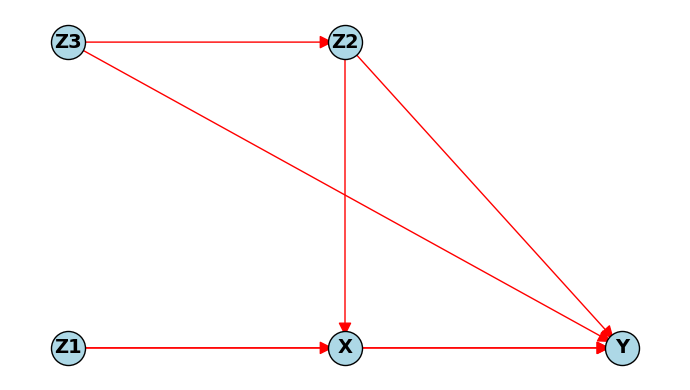

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

# Define nodes and edges
G = nx.DiGraph()
G.add_edges_from([
    ("Z1", "X"), ("Z1", "Y"),
    ("Z2", "X"), ("Z2", "Y"),
    ("Z3", "Z2"), ("Z3", "Y"),
    ("X", "Y"),
])

# Fixed positions
pos = {
    "Z3": (0.0, 1.8),
    "Z2": (1.2, 1.8),
    "Z1": (0.0, 0.9),
    "X":  (1.2, 0.9),
    "Y":  (2.4, 0.9),
}

plt.figure(figsize=(7,4))

# Draw nodes
nx.draw_networkx_nodes(
    G, pos, 
    node_size=600,      # circle size
    node_color="lightblue", 
    edgecolors="black"  # node border
)

# Draw labels
nx.draw_networkx_labels(
    G, pos, 
    font_size=14, 
    font_family="sans-serif", 
    font_color="black", 
    font_weight="bold"
)

# Draw edges
nx.draw_networkx_edges(
    G, pos, 
    edge_color="red", 
    arrowsize=20,    # arrow size
    width=1          # line width
)

plt.axis("off")
plt.tight_layout()

# Save figure to folder [[UPDATE WHEN MAIN IS CREATED]]
plt.savefig(URL + "DAG_Can_We_Omite_Some_Control.png",
            dpi=300, bbox_inches="tight")

# Show in notebook
plt.show()


## 2.2) Simulation (1 point)

In [20]:
import numpy as np, pandas as pd
import statsmodels.api as sm
np.random.seed(123); n=5000
e = lambda m: np.random.normal(size=n)

Z3 = e('z3')
Z2 = Z3 + e('z2')
Z1 = e('z1')
X  = Z1 + Z2 + e('x')
Y  = X + Z1 + Z2 + Z3 + e('y')

df = pd.DataFrame({'Y':Y,'X':X,'Z1':Z1,'Z2':Z2,'Z3':Z3})

## 2.3) Regressions (2 point)

In [21]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Helper: OLS with intercept and HC1 SEs
def fit(y, X):
    Xc = sm.add_constant(X, has_constant="add")
    return sm.OLS(y, Xc).fit(cov_type="HC1")

# Fit models matching the labels
m1 = fit(df["Y"], df[["X"]])
m2 = fit(df["Y"], df[["X", "Z1"]])
m3 = fit(df["Y"], df[["X", "Z2"]])
m4 = fit(df["Y"], df[["X", "Z1", "Z2"]])
m5 = fit(df["Y"], df[["X", "Z1", "Z2", "Z3"]])

models = [m1, m2, m3, m4, m5]
labels = ["(1) Y~X",
          "(2) Y~X+Z1",
          "(3) Y~X+Z2",
          "(4) Y~X+Z1+Z2",
          "(5) Y~X+Z1+Z2+Z3"]

# Build summary rows
def row_from_model(res, name="X"):
    est = res.params[name]
    se  = res.bse[name]
    t   = est / se
    p   = res.pvalues[name]
    z   = 2.575  # 99% CI z-quantile
    ci  = (est - z*se, est + z*se)
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    return {
        "Coef X": est,
        "SE(X)": se,
        "CI99%": f"[{ci[0]:.3f}, {ci[1]:.3f}]",
        "t(X)": t,
        "p(X)": p,
        "Sig": stars,
        "R2": res.rsquared,
        "n": int(res.nobs)
    }

summary = pd.DataFrame([row_from_model(m) for m in models], index=labels)

# Pretty print
fmt = summary.copy()
fmt["Coef X"] = fmt["Coef X"].map(lambda v: f"{v:,.3f}")
fmt["SE(X)"]  = fmt["SE(X)"].map(lambda v: f"{v:,.3f}")
fmt["t(X)"]   = fmt["t(X)"].map(lambda v: f"{v:,.2f}")
fmt["p(X)"]   = fmt["p(X)"].map(lambda v: f"{v:.3g}")
fmt["R2"]     = fmt["R2"].map(lambda v: f"{v:.3f}")
fmt["n"]      = fmt["n"].map("{:,}".format)

display(fmt)



,Coef X,SE(X),CI99%,t(X),p(X),Sig,R2,n
(1) Y~X,1.985,0.012,"[1.954, 2.015]",168.20,0,***,0.846,"5,000"
(2) Y~X+Z1,1.987,0.014,"[1.951, 2.022]",143.99,0,***,0.846,"5,000"
(3) Y~X+Z2,1.483,0.014,"[1.448, 1.519]",108.69,0,***,0.899,"5,000"
(4) Y~X+Z1+Z2,0.998,0.017,"[0.954, 1.042]",58.81,0,***,0.923,"5,000"
(5) Y~X+Z1+Z2+Z3,0.993,0.013,"[0.958, 1.027]",73.91,0,***,0.950,"5,000"


## 2.4) 99% Confidence Intervals (2 point)

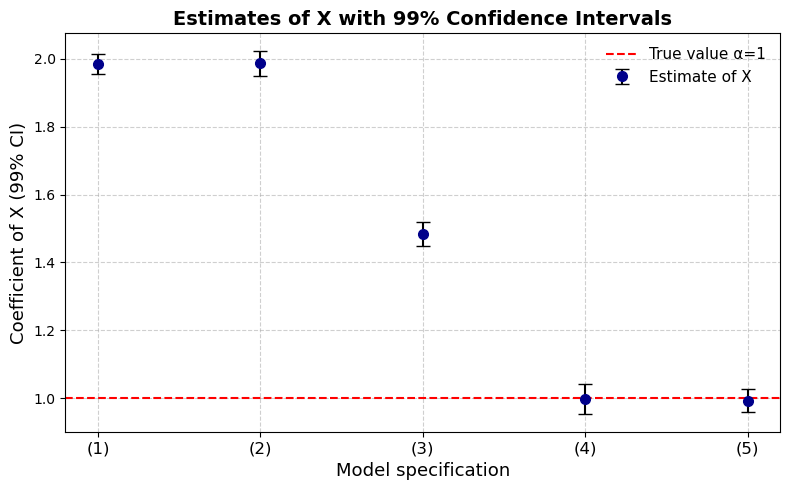

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Define helper function
def ci99(model, var="X"):
    est = model.params[var]
    se  = model.bse[var]
    z   = 2.575  # 99% z critical value
    lo, hi = est - z*se, est + z*se
    return est, se, lo, hi

# Collect estimates and confidence intervals
ests, los, his = [], [], []
for m in [m1, m2, m3, m4, m5]:
    est, se, lo, hi = ci99(m, 'X')
    ests.append(est); los.append(lo); his.append(hi)

x = np.arange(1, 6)

fig, ax = plt.subplots(figsize=(8,5))

# Plot estimates with error bars
ax.errorbar(x, ests,
            yerr=[np.array(ests)-np.array(los),
                  np.array(his)-np.array(ests)],
            fmt='o', markersize=7,
            ecolor='black', elinewidth=1.5, capsize=5,
            color='darkblue', label='Estimate of X')

# Reference line
ax.axhline(1, linestyle='--', color='red', linewidth=1.5, label='True value α=1')

# Style
ax.set_xticks(x)
ax.set_xticklabels(['(1)', '(2)', '(3)', '(4)', '(5)'], fontsize=12)
ax.set_xlabel("Model specification", fontsize=13)
ax.set_ylabel("Coefficient of X (99% CI)", fontsize=13)
ax.set_title("Estimates of X with 99% Confidence Intervals", fontsize=14, weight='bold')
ax.legend(frameon=False, fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(URL + "DAG_Confidence Intervals.png",
            dpi=300, bbox_inches="tight")
plt.show()


## Questions

### 2.5). Which regressions correctly estimate the effect?  (1 point)
The regressions that provide an unbiased estimate of the causal effect of $X$ on $Y$ are **(4)** and **(5)**.  
In (4) $Y \sim X + Z_{1} + Z_{2}$ all backdoors are blocked by controlling for the confounders $Z_{1}, Z_{2}$.  
In (5) $Y \sim X + Z_{1} + Z_{2} + Z_{3}$ as well, but $Z_{3}$ is redundant since it is an ancestor of $Z_{2}$.


### 2.6). Summary table (models 4 and 5) (0.5 point)

| Model | $\hat{\alpha}_{X}$ | SE($\hat{\alpha}_{X}$) | 99% CI          | $R^{2}$ | $n$   |
|:-----:|:------------------:|:----------------------:|:---------------:|:-------:|:-----:|
|  (4)  | 0.998              | 0.017                  | [0.954, 1.042]  | 0.923   | 5000  |
|  (5)  | 0.993              | 0.014                  | [0.957, 1.028]  | 0.950   | 5000  |

**Comment.** $\hat{\alpha}_{X}$ is very close to $\alpha=1$; the 99% confidence intervals include 1; the standard errors are small.  
The higher $R^{2}$ in (5) results from adding $Z_{3}$, which is unnecessary for identification.


### 2.7). Can any $Z$ be ignored?  (0.5 point)
Yes. $Z_{3}$ can be omitted. With $\{Z_{1}, Z_{2}\}$ the backdoor criterion is already satisfied; including $Z_{3}$ does not reduce bias and may harm efficiency due to collinearity.

**Conclusion.** The minimally sufficient adjustment set is $\{Z_{1}, Z_{2}\}$.



# Part 3 - Damned if you do, damned if you don't (9 points)


## 3.1) Graphic DAG (1 point) 

NameError: name 'URL' is not defined

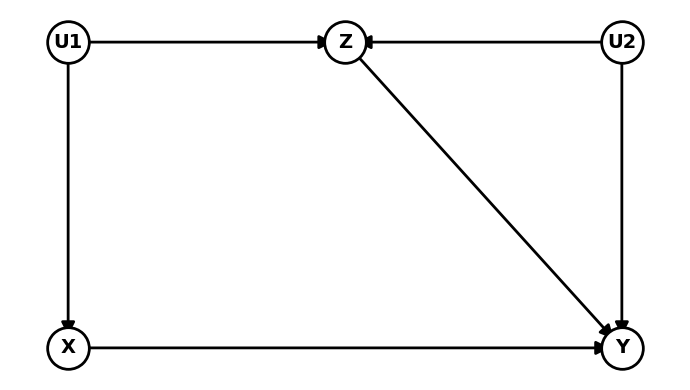

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# DAG: U1→Z, U2→Z, U1→X, Z→Y, U2→Y, X→Y
G = nx.DiGraph()
G.add_edges_from([
    ("U1", "Z"),
    ("U2", "Z"),
    ("U1", "X"),
    ("Z",  "Y"),
    ("U2", "Y"),
    ("X",  "Y"),
])

# Positions to resemble the diagram
pos = {
    "U1": (0.0, 1.2),
    "Z":  (1.2, 1.2),
    "U2": (2.4, 1.2),
    "X":  (0.0, 0.0),
    "Y":  (2.4, 0.0),
}

plt.figure(figsize=(7,4))

# Nodes
nx.draw_networkx_nodes(
    G, pos, node_size=900, node_color="white", edgecolors="black", linewidths=2
)

# Labels
nx.draw_networkx_labels(G, pos, font_size=14, font_weight="bold")

# Edges
nx.draw_networkx_edges(
    G, pos, arrows=True, arrowstyle="-|>", arrowsize=20, width=2, connectionstyle="arc3"
)

plt.axis("off")
plt.tight_layout()

# Save (optional)
plt.savefig(URL + "DAG_damned.png",
            dpi=300, bbox_inches="tight")

plt.show()



## 3.2) Regressions (1 point) 

In [31]:
import numpy as np, pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(123)
n = 50000

# Exogenous shocks
U1 = np.random.normal(size=n)
U2 = np.random.normal(size=n)

# DAG definition
Z = U1 + U2 + np.random.normal(size=n)            # collider
X = U1 + np.random.normal(size=n)                 # treatment
Y = 1*X + 1*U2 + 1*Z + np.random.normal(size=n)   # outcome

df = pd.DataFrame({"Y":Y, "X":X, "Z":Z, "U1":U1, "U2":U2})

# OLS function with intercept
def fit(y, X):
    Xc = sm.add_constant(X, has_constant='add')
    return sm.OLS(y, Xc).fit(cov_type='HC1')

# 1) Model without controlling for Z
m0 = fit(df["Y"], df[["X"]])

# 2) Model controlling for Z
m1 = fit(df["Y"], df[["X","Z"]])

# Short summary
def report(res, var):
    est = res.params[var]; se = res.bse[var]
    lo, hi = res.conf_int().loc[var]
    return f"{var}: {est:.3f} (SE={se:.3f}, 95% CI [{lo:.3f},{hi:.3f}])"

print("== Y ~ X ==")
print(report(m0,"X"))

print("\n== Y ~ X + Z ==")
print(report(m1,"X"))


== Y ~ X ==
X: 1.507 (SE=0.008, 95% CI [1.491,1.523])

== Y ~ X + Z ==
X: 0.811 (SE=0.004, 95% CI [0.802,0.820])


## 3.3) 99% Confidence Intervals (1 point)

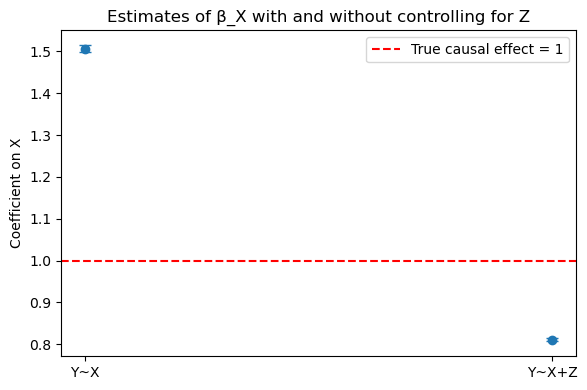

In [32]:
# Extract coefficient and SE of X
ests = [m0.params["X"], m1.params["X"]]
ses  = [m0.bse["X"],   m1.bse["X"]]
labels = ["Y~X", "Y~X+Z"]

# Plot
plt.figure(figsize=(6,4))
plt.errorbar(range(len(ests)), ests, yerr=ses, fmt='o', capsize=4)
plt.axhline(1.0, color='red', linestyle='--', label='True causal effect = 1')
plt.xticks(range(len(ests)), labels)
plt.ylabel("Coefficient on X")
plt.title("Estimates of β_X with and without controlling for Z")
plt.legend()
plt.tight_layout()

# Save figure
plt.savefig( URL + "estimates_X.png",
            dpi=300, bbox_inches="tight")

# Show figure
plt.show()


## Opinion
The plot illustrates Simpson’s paradox in the “Damned if you do, damned if you don’t” setting.  

- When regressing $Y$ on $X$ without controls, the coefficient of $X$ is biased upward ($\hat\beta_X \approx 1.5$), far from the true causal effect of $1$.  
- When controlling for $Z$, which is a collider, the coefficient flips downward ($\hat\beta_X \approx 0.8$), also biased.  
- In both cases, the estimates fail to recover the true causal effect. This shows that adjusting for the wrong variable (a collider) can introduce bias, while omitting it does not solve the problem either.  



## 3.4) Variation of "Damned if you do, damned if you don't" - Graph & Simulation (0.5 points)

C:\Users\User\AppData\Local\Temp\ipykernel_5192\2618650926.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


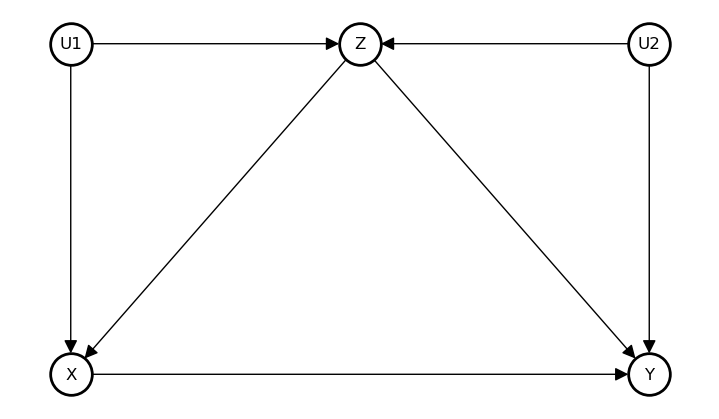

In [33]:
import networkx as nx
import matplotlib.pyplot as plt

# Define the DAG
G = nx.DiGraph()
G.add_edges_from([
    ("U1", "Z"),
    ("U2", "Z"),
    ("Z",  "X"),
    ("U1", "X"),
    ("X",  "Y"),
    ("Z",  "Y"),
    ("U2", "Y")
])

# Fixed positions
pos = {
    "U1": (0, 1.2),
    "Z":  (1.2, 1.2),
    "U2": (2.4, 1.2),
    "X":  (0, 0),
    "Y":  (2.4, 0)
}

plt.figure(figsize=(7,4))

# Draw DAG
nx.draw(
    G, pos,
    with_labels=True,
    node_color="white",
    edgecolors="black",
    node_size=900,
    arrows=True,
    arrowsize=20,
    linewidths=2
)

plt.axis("off")
plt.tight_layout()

# Save figure
plt.savefig( URL + "DAG_DAM_Alt.png",
            dpi=300, bbox_inches="tight")

# Show figure
plt.show()



In [34]:
import numpy as np, pandas as pd
np.random.seed(123); n=50000

U1 = np.random.normal(size=n)
U2 = np.random.normal(size=n)
Z  = 0.8*U1 + 0.8*U2 + np.random.normal(size=n)   # U1→Z, U2→Z
X  = 0.9*U1 + 0.7*Z  + np.random.normal(size=n)   # Z→X, U1→X
Y  = 1.0*X + 1.0*Z + 1.0*U2 + np.random.normal(size=n)  # X→Y, Z→Y, U2→Y

df = pd.DataFrame({"Y":Y,"X":X,"Z":Z,"U1":U1,"U2":U2})



## 3.5) Regressions (1.5 points)

In [35]:
import itertools
import numpy as np
import pandas as pd
import statsmodels.api as sm

def fit(y, X):
    Xc = sm.add_constant(X, has_constant='add')
    return sm.OLS(y, Xc).fit(cov_type='HC1')

# --- 1) Estimate ALL combinations and REPORT in academic format ---
controls_pool = ["Z", "U1", "U2"]
specs = []
for k in range(0, len(controls_pool)+1):
    specs += list(itertools.combinations(controls_pool, k))

models = {}

print("== Regression results for β_X (academic format) ==")
print("-" * 90)
print(f"{'Model':<20} {'β_X':>10} {'SE':>10} {'95% CI':>22} {'p-value':>10} {'R²':>8} {'n':>6}")
print("-" * 90)

for comb in specs:
    label = "No controls" if len(comb) == 0 else " + ".join(comb)
    cols  = ["X"] + list(comb)
    m     = fit(df["Y"], df[cols])
    models[label] = m  # store model

    est = m.params["X"]; se = m.bse["X"]; p = m.pvalues["X"]
    lo, hi = m.conf_int().loc["X"]
    n = int(m.nobs); r2 = m.rsquared

    print(f"{label:<20} {est:10.4f} {se:10.4f} "
          f"[{lo:.4f}, {hi:.4f}] {p:10.3g} {r2:8.3f} {n:6d}")

print("-" * 90)


== Regression results for β_X (academic format) ==
------------------------------------------------------------------------------------------
Model                       β_X         SE                 95% CI    p-value       R²      n
------------------------------------------------------------------------------------------
No controls              1.7364     0.0044 [1.7279, 1.7450]          0    0.759  50000
Z                        0.8515     0.0046 [0.8423, 0.8606]          0    0.892  50000
U1                       1.9456     0.0063 [1.9333, 1.9580]          0    0.769  50000
U2                       1.5168     0.0030 [1.5109, 1.5228]          0    0.894  50000
Z + U1                   1.0096     0.0057 [0.9984, 1.0208]          0    0.897  50000
Z + U2                   1.0095     0.0037 [1.0023, 1.0167]          0    0.936  50000
U1 + U2                  1.4674     0.0047 [1.4581, 1.4766]          0    0.894  50000
Z + U1 + U2              1.0094     0.0045 [1.0006, 1.0181]      

## 3.6) Summary Table ( Coef and SE) (1 points)

In [36]:
# --- 2) Save ONLY estimate and standard error in a DataFrame ---
rows = []
for label, m in models.items():
    rows.append({
        "Controls": label,
        "β_X": m.params["X"],
        "SE(β_X)": m.bse["X"]
    })

results_df = pd.DataFrame(rows).set_index("Controls")

# Order: No controls first, then by number of covariates
results_df = results_df.loc[
    sorted(results_df.index, key=lambda s: (s != "No controls", s.count("+"), s))
]

print("\n== Stored estimates (for downstream use) ==")
print("-" * 50)
print(results_df.round(4).to_string())
print("-" * 50)




== Stored estimates (for downstream use) ==
--------------------------------------------------
                β_X  SE(β_X)
Controls                    
No controls  1.7364   0.0044
U1           1.9456   0.0063
U2           1.5168   0.0030
Z            0.8515   0.0046
U1 + U2      1.4674   0.0047
Z + U1       1.0096   0.0057
Z + U2       1.0095   0.0037
Z + U1 + U2  1.0094   0.0045
--------------------------------------------------


## 3.7) .text and .txt format ( Coef and SE) (1.5 points)

In [37]:
import itertools, os
import pandas as pd
import statsmodels.api as sm

# OLS helper with intercept and HC1 SEs
def fit(y, X):
    Xc = sm.add_constant(X, has_constant='add')
    return sm.OLS(y, Xc).fit(cov_type='HC1')

# All control combinations from {Z, U1, U2}
controls_pool = ["Z", "U1", "U2"]
specs = [tuple()]
for k in range(1, len(controls_pool) + 1):
    specs += list(itertools.combinations(controls_pool, k))

# Estimate and collect β and SE for X
rows = []
for comb in specs:
    label = "No controls" if len(comb) == 0 else ", ".join(comb)
    cols  = ["X"] + list(comb)
    m     = fit(df["Y"], df[cols])
    rows.append({"Controls": label, "β": m.params["X"], "SE": m.bse["X"]})

table = pd.DataFrame(rows).set_index("Controls")

# Order: No controls first, then by number of controls, then alphabetically
table = table.loc[
    sorted(table.index, key=lambda s: (s != "No controls", s.count(",") + (s != "No controls"), s))
].round(4)

# Export TXT (tab-separated) and LaTeX
txt_path = os.path.join(URL, "table_beta_se.txt")
tex_path = os.path.join(URL, "table_beta_se.tex")

table.to_csv(txt_path, sep="\t", float_format="%.4f")
with open(tex_path, "w", encoding="utf-8") as f:
    f.write(table.to_latex(escape=False, float_format="%.4f"))

print(f"Saved TXT: {txt_path}")
print(f"Saved LaTeX: {tex_path}")
print("\n== Stored estimates (β and SE) ==")
print(table.to_string())


Saved TXT: C:\\Users\\User\\Desktop\\Avances Asignación 03\\Python\\Output\\table_beta_se.txt
Saved LaTeX: C:\\Users\\User\\Desktop\\Avances Asignación 03\\Python\\Output\\table_beta_se.tex

== Stored estimates (β and SE) ==
                  β      SE
Controls                   
No controls  1.7364  0.0044
U1           1.9456  0.0063
U2           1.5168  0.0030
Z            0.8515  0.0046
U1, U2       1.4674  0.0047
Z, U1        1.0096  0.0057
Z, U2        1.0095  0.0037
Z, U1, U2    1.0094  0.0045


# 3.8) Based on your findings, in what way(s) can you get a good estimate of the causal effect? (0.5 point)

From the regression results, we know the true causal effect of $X$ on $Y$ is $1$.  
- Models without controls or with only one control ($Z$, $U1$, $U2$) are **biased**, as their estimates are far from $1$ (e.g., $1.7364$, $0.8515$, $1.9456$, $1.5168$).  
- Good estimates (close to $1$ with narrow CIs) are obtained only when controlling simultaneously for $Z$ and at least one of the true confounders ($U1$, $U2$).  
- For instance:  
  - $Y \sim X + Z + U1 \;\;\; \hat\beta_X \approx 1.0096$  
  - $Y \sim X + Z + U2 \;\;\; \hat\beta_X \approx 1.0095$  
  - $Y \sim X + Z + U1 + U2 \;\;\; \hat\beta_X \approx 1.0094$  

All these estimates are very close to the true value of $1$ and unbiased within sampling error.



# 3.9) What is the minimal sufficient set of controls to get a good estimate? (0.5 point)

The minimal sufficient adjustment set is **$\{Z, U1\}$** or alternatively **$\{Z, U2\}$**.  
Controlling only $Z$ introduces collider bias, and controlling only $U1$ or $U2$ leaves confounding unaddressed. But once $Z$ and one of the confounders are included, the backdoor paths are blocked, yielding unbiased estimates of $\beta_X$.



# 3.10) Provide intuition on why you can get good estimates controlling for the variables you established above (0.5 point)

- $U1$ and $U2$ are true confounders because they influence both $X$ and $Y$.  
- $Z$ is a collider that also has a direct effect on $Y$ and an effect on $X$. If omitted, $Z$ creates bias in the regression of $Y$ on $X$.  
- By controlling for $Z$ and one of the confounders ($U1$ or $U2$), we block the spurious paths:  
  - $X \leftarrow U1 \rightarrow Y$  
  - $X \leftarrow Z \leftarrow U2 \rightarrow Y$  
- This ensures that the only remaining path from $X$ to $Y$ is the **causal path**, so the regression recovers the true causal effect $\beta_X = 1$.  
